In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline   

df = pd.read_csv("../data/amazon.csv")
df.head()


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
import numpy as np

# Making copy so that orginal dataset remains safe
df_clean = df.copy()

# 1) Cleaned price columns: discounted_price & actual_price
for col in ["discounted_price", "actual_price"]:
    df_clean[col] = (
        df_clean[col].astype(str)
        .str.replace("₹", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# 2) Cleaned discount percentage column
df_clean["discount_percentage"] = (
    df_clean["discount_percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

# 3) Converted rating & rating_count to numbers
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")

df_clean["rating_count"] = (
    df_clean["rating_count"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df_clean["rating_count"] = pd.to_numeric(df_clean["rating_count"], errors="coerce")

# 4) Extracted main category (first part before "|")
df_clean["main_category"] = df_clean["category"].str.split("|").str[0]


df_clean[[
    "discounted_price", "actual_price", "discount_percentage",
    "rating", "rating_count", "main_category"
]].head()


,discounted_price,actual_price,discount_percentage,rating,rating_count,main_category
0,399.0,1099.0,64.0,4.2,24269.0,Computers&Accessories
1,199.0,349.0,43.0,4.0,43994.0,Computers&Accessories
2,199.0,1899.0,90.0,3.9,7928.0,Computers&Accessories
3,329.0,699.0,53.0,4.2,94363.0,Computers&Accessories
4,154.0,399.0,61.0,4.2,16905.0,Computers&Accessories


In [6]:
# 1) Discount amount (₹)
df_clean["discount_amount"] = df_clean["actual_price"] - df_clean["discounted_price"]

# 2) Discount ratio (0–1)
df_clean["discount_ratio"] = df_clean["discount_amount"] / df_clean["actual_price"]

# 3) Popularity score = rating * log(1 + rating_count)
df_clean["popularity_score"] = (
    df_clean["rating"].fillna(0) * np.log1p(df_clean["rating_count"].fillna(0))
)

# 4) Price bands for analysis
bins = [0, 500, 1000, 2000, 5000, 100000]
labels = ["<=500", "500-1k", "1k-2k", "2k-5k", ">5k"]
df_clean["price_band"] = pd.cut(df_clean["discounted_price"], bins=bins, labels=labels)

# preview
df_clean[[
    "discounted_price", "actual_price", "discount_amount",
    "discount_ratio", "popularity_score", "price_band"
]].head()


,discounted_price,actual_price,discount_amount,discount_ratio,popularity_score,price_band
0,399.0,1099.0,700.0,0.636943,42.407384,<=500
1,199.0,349.0,150.0,0.429799,42.767325,<=500
2,199.0,1899.0,1700.0,0.895208,35.015301,<=500
3,329.0,699.0,370.0,0.529328,48.110643,<=500
4,154.0,399.0,245.0,0.614035,40.888780,<=500


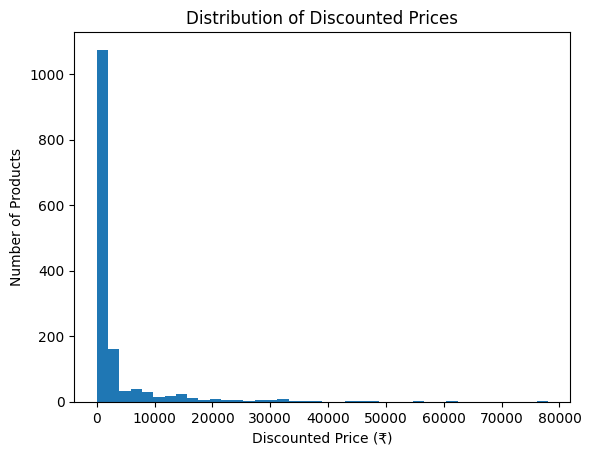

In [7]:
df_clean["discounted_price"].plot(kind="hist", bins=40)
plt.xlabel("Discounted Price (₹)")
plt.ylabel("Number of Products")
plt.title("Distribution of Discounted Prices")
plt.show()


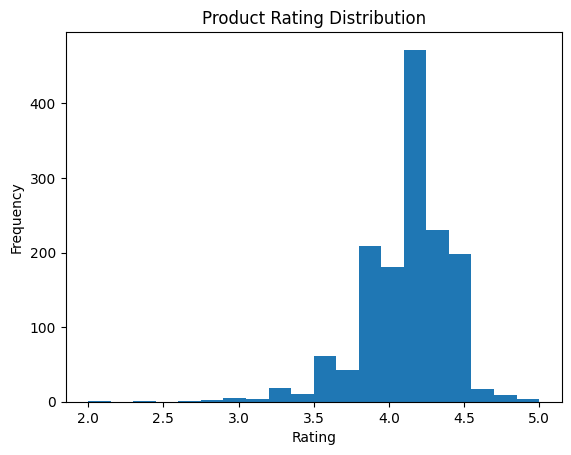

In [8]:
df_clean["rating"].plot(kind="hist", bins=20)
plt.xlabel("Rating")
plt.title("Product Rating Distribution")
plt.show()


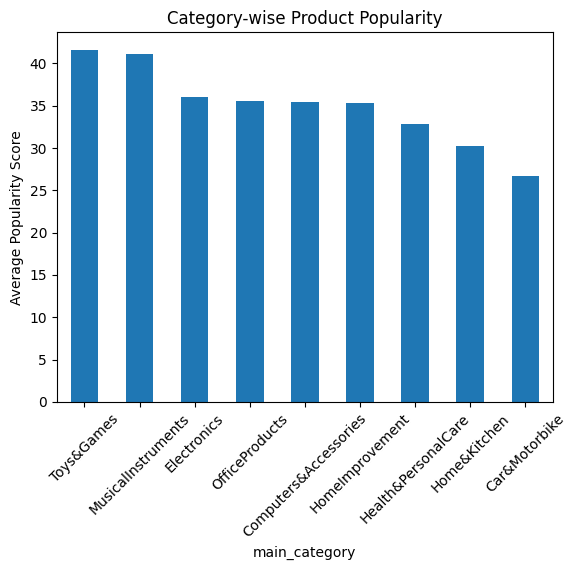

In [9]:
cat_pop = (
    df_clean.groupby("main_category")["popularity_score"]
    .mean()
    .sort_values(ascending=False)
)

cat_pop.plot(kind="bar")
plt.ylabel("Average Popularity Score")
plt.title("Category-wise Product Popularity")
plt.xticks(rotation=45)
plt.show()


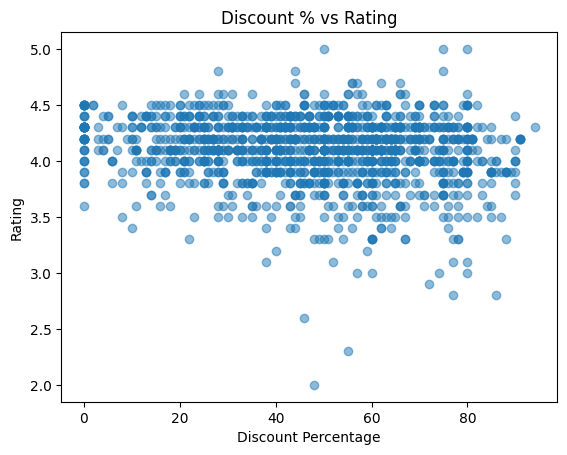

In [10]:
plt.scatter(df_clean["discount_percentage"], df_clean["rating"], alpha=0.5)
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")
plt.title("Discount % vs Rating")
plt.show()


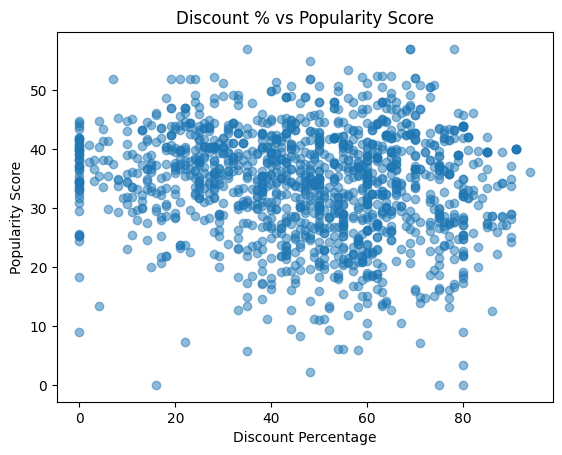

In [11]:
plt.scatter(df_clean["discount_percentage"], df_clean["popularity_score"], alpha=0.5)
plt.xlabel("Discount Percentage")
plt.ylabel("Popularity Score")
plt.title("Discount % vs Popularity Score")
plt.show()


In [12]:
discount_bins = [0, 20, 40, 60, 80, 100]
discount_labels = ["0–20%", "20–40%", "40–60%", "60–80%", "80–100%"]

df_clean["discount_bucket"] = pd.cut(
    df_clean["discount_percentage"], bins=discount_bins, labels=discount_labels
)

discount_analysis = (
    df_clean.groupby("discount_bucket")
    .agg(
        avg_rating=("rating", "mean"),
        avg_popularity=("popularity_score", "mean"),
        count=("product_name", "count")
    )
    .reset_index()
)

discount_analysis


C:\Users\Admin\AppData\Local\Temp\ipykernel_21260\3551750921.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby("discount_bucket")


,discount_bucket,avg_rating,avg_popularity,count
0,0–20%,4.146923,35.822894,131
1,20–40%,4.126331,35.937801,338
2,40–60%,4.079331,32.623424,508
3,60–80%,4.076053,33.755843,380
4,80–100%,3.976271,33.103174,59


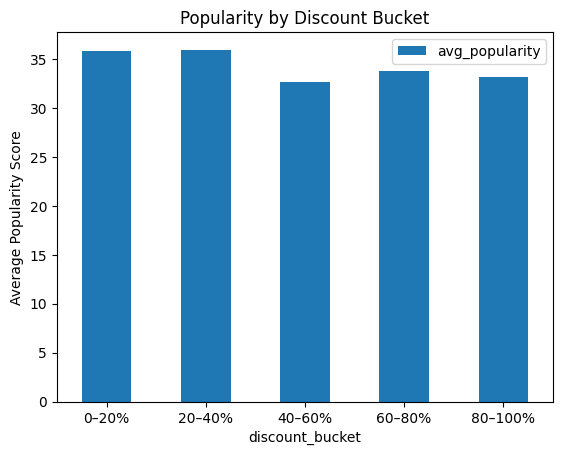

In [13]:
discount_analysis.set_index("discount_bucket")[["avg_popularity"]].plot(kind="bar")
plt.ylabel("Average Popularity Score")
plt.title("Popularity by Discount Bucket")
plt.xticks(rotation=0)
plt.show()


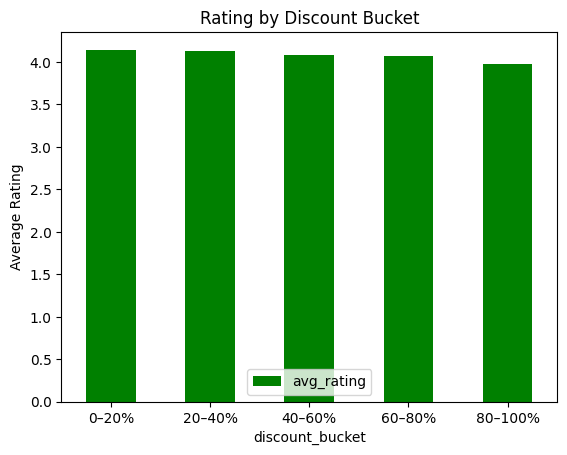

In [14]:
discount_analysis.set_index("discount_bucket")[["avg_rating"]].plot(kind="bar", color='green')
plt.ylabel("Average Rating")
plt.title("Rating by Discount Bucket")
plt.xticks(rotation=0)
plt.show()


In [15]:
df_clean.to_csv("../data/amazon_cleaned.csv", index=False)


In [16]:
pip install textblob nltk wordcloud

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 1.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 1.2 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.5 MB 1.0 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.4 MB/s  0:00:00

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [nltk]
   ------

In [17]:
from textblob import TextBlob
import nltk
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [18]:
def get_sentiment(text):
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    return polarity

df_clean['sentiment_score'] = df_clean['review_content'].apply(get_sentiment)


In [19]:
def label_sentiment(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df_clean['sentiment_label'] = df_clean['sentiment_score'].apply(label_sentiment)
df_clean[['review_content','sentiment_score','sentiment_label']].head(10)


,review_content,sentiment_score,sentiment_label
0,Looks durable Charging is fine tooNo complains...,0.481944,Positive
1,I ordered this cable to connect my phone to An...,0.274318,Positive
2,"Not quite durable and sturdy,https://m.media-a...",0.600000,Positive
3,"Good product,long wire,Charges good,Nice,I bou...",0.240370,Positive
4,"Bought this instead of original apple, does th...",0.262740,Positive
5,"It's a good product.,Like,Very good item stron...",0.486667,Positive
6,Build quality is good and it is comes with 2 y...,0.677778,Positive
7,Worth for money - suitable for Android auto......,0.376042,Positive
8,I use this to connect an old PC to internet. I...,0.278941,Positive
9,I ordered this cable to connect my phone to An...,0.274318,Positive


In [20]:
sentiment_summary = df_clean.groupby("sentiment_label").size().reset_index(name="count")
sentiment_summary['percentage'] = (sentiment_summary['count'] / sentiment_summary['count'].sum()) * 100

sentiment_summary


,sentiment_label,count,percentage
0,Negative,11,0.750853
1,Neutral,100,6.825939
2,Positive,1354,92.423208


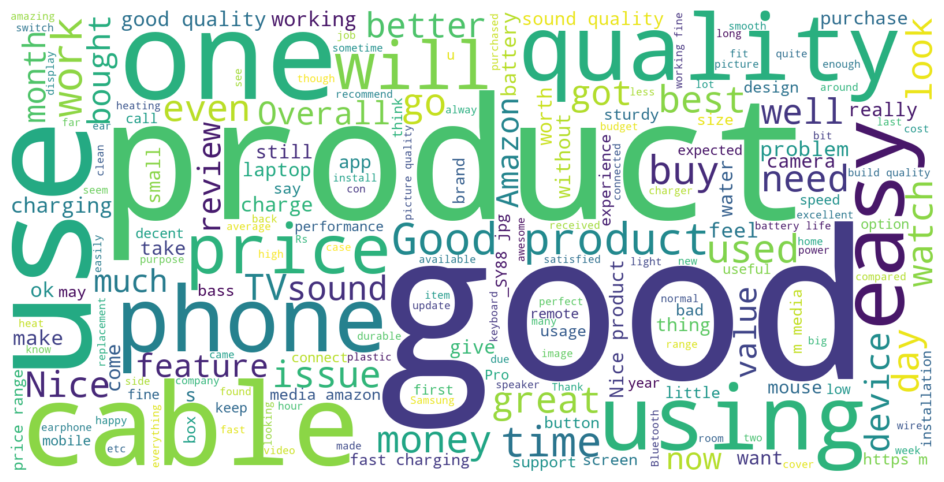

In [21]:
text = " ".join(df_clean['review_content'].astype(str).tolist())

wordcloud = WordCloud(stopwords=STOPWORDS,
                       background_color="white",
                       width=1600, height=800).generate(text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [22]:
df_clean.to_csv("../data/amazon_sentiment_ready.csv", index=False)


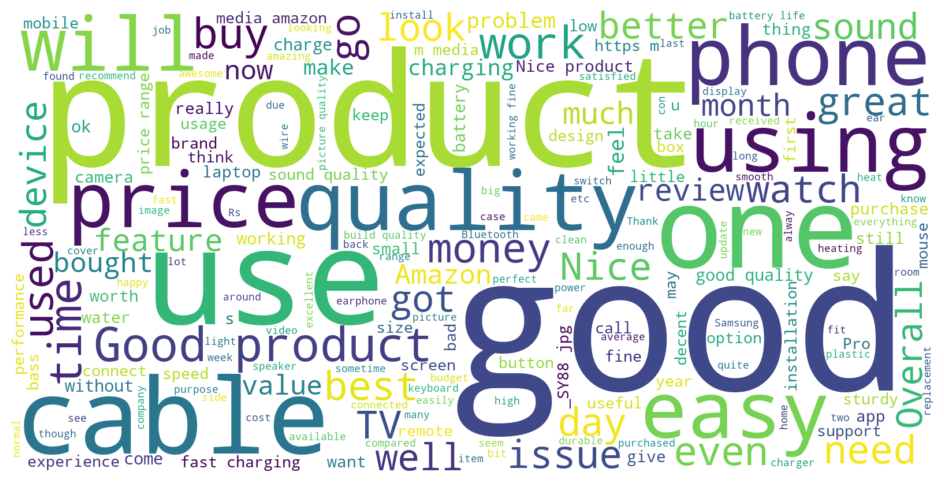

In [23]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine all reviews into single text
text = " ".join(df_clean['review_content'].astype(str).tolist())

# Generate WordCloud
wordcloud = WordCloud(stopwords=STOPWORDS, background_color="white",
                      width=1600, height=800).generate(text)

# Display
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")


wordcloud.to_file("wordcloud.png")
